# Amazon Sales Analysis

## Business Problem

The objective of this analysis is to identify:
- Top-performing categories
- Revenue-driving states
- Impact of cancellations on revenue
- Fulfillment performance
- Opportunities to improve sales and customer experience

In [32]:
from numpy._core.fromnumeric import amax
import pandas as pd
import numpy as np
df=pd.read_csv('Amazon Sale Report.csv')
df.info()
df.head()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42819 entries, 0 to 42818
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               42819 non-null  int64  
 1   Order ID            42819 non-null  object 
 2   Date                42819 non-null  object 
 3   Status              42819 non-null  object 
 4   Fulfilment          42818 non-null  object 
 5   Sales Channel       42818 non-null  object 
 6   ship-service-level  42818 non-null  object 
 7   Category            42818 non-null  object 
 8   Size                42818 non-null  object 
 9   Courier Status      42818 non-null  object 
 10  Qty                 42818 non-null  float64
 11  currency            40218 non-null  object 
 12  Amount              40218 non-null  float64
 13  ship-city           42803 non-null  object 
 14  ship-state          42803 non-null  object 
 15  ship-postal-code    42803 non-null  float64
 16  ship

/tmp/ipykernel_10117/2084770469.py:4: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Amazon Sale Report.csv')


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [33]:
df.describe()

,index,Qty,Amount,ship-postal-code,New,PendingS
count,42819.000000,42818.000000,40218.000000,42803.000000,0.0,0.0
mean,21406.886803,0.900112,624.645113,463739.651917,NaN,NaN
std,12362.392207,0.331448,272.248921,194444.903412,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,10703.500000,1.000000,432.000000,380015.000000,NaN,NaN
50%,21408.000000,1.000000,568.000000,500019.000000,NaN,NaN
75%,32112.500000,1.000000,771.000000,600033.000000,NaN,NaN
max,42817.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [34]:
df.shape

(42819, 21)

In [35]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,1
Sales Channel,1
ship-service-level,1
Category,1
Size,1
Courier Status,1


In [36]:
df[df['Amount'].isnull()][['Status','Amount','currency']].head()

,Status,Amount,currency
8,Cancelled,NaN,NaN
29,Cancelled,NaN,NaN
65,Cancelled,NaN,NaN
84,Cancelled,NaN,NaN
95,Cancelled,NaN,NaN


In [37]:
df[df['Amount'].isnull()]['Status'].value_counts()

,count
Status,
Cancelled,2519
Shipped,77
Shipped - Delivered to Buyer,4
Shipped - Delivered to Buy,1


In [38]:
cancelled_orders = df[df['Status'] == 'Cancelled']

cancelled_orders.groupby('Category').size().sort_values(ascending=False)

,0
Category,
Shirt,2640
T-shirt,2559
Blazzer,493
Trousers,385
Wallet,52
Perfume,45
Socks,15
Shoes,9


In [39]:
category_cancel_rate = (
    df.assign(Cancelled=df['Status']=='Cancelled')
      .groupby('Category')['Cancelled']
      .mean()*100
)

category_cancel_rate.sort_values(ascending=False)

,Cancelled
Category,
Shirt,15.223158
T-shirt,14.655518
Perfume,14.331210
Wallet,13.941019
Shoes,13.235294
Blazzer,13.104732
Trousers,11.565035
Socks,8.875740


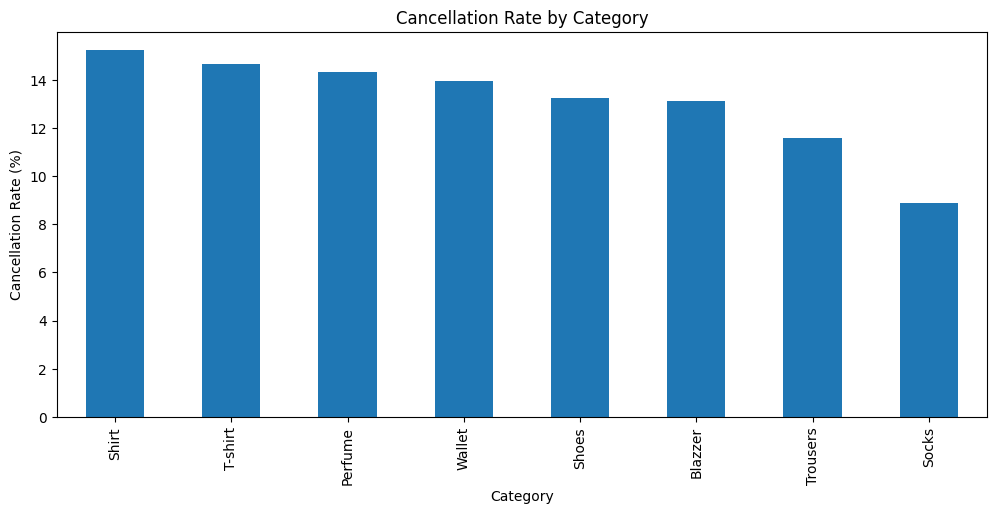

In [40]:
import matplotlib.pyplot as plt

category_cancel_rate.sort_values(ascending=False).plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Cancellation Rate by Category")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [41]:
category_revenue = (
    df.groupby('Category')['Amount']
      .sum()
      .sort_values(ascending=False)
)

category_revenue

,Amount
Category,
T-shirt,13432555.78
Shirt,7017463.58
Blazzer,2616066.78
Trousers,1550057.69
Perfume,220369.65
Wallet,173992.45
Socks,59960.97
Shoes,51510.24


In [42]:
analysis = pd.DataFrame({
    'Revenue': df.groupby('Category')['Amount'].sum(),
    'Orders': df.groupby('Category').size(),
    'Cancellation_Rate': (
        df.assign(Cancelled=df['Status']=='Cancelled')
          .groupby('Category')['Cancelled']
          .mean()*100
    )
})

analysis.sort_values('Revenue', ascending=False)

,Revenue,Orders,Cancellation_Rate
Category,,,
T-shirt,13432555.78,17461,14.655518
Shirt,7017463.58,17342,15.223158
Blazzer,2616066.78,3762,13.104732
Trousers,1550057.69,3329,11.565035
Perfume,220369.65,314,14.331210
Wallet,173992.45,373,13.941019
Socks,59960.97,169,8.875740
Shoes,51510.24,68,13.235294


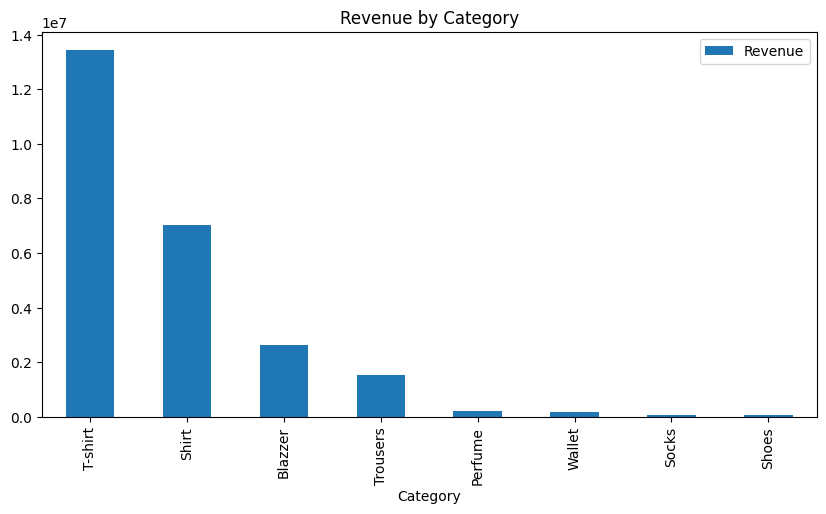

In [43]:
analysis.sort_values('Revenue', ascending=False).plot(
    kind='bar',
    y='Revenue',
    figsize=(10,5)
)
plt.title("Revenue by Category")
plt.show()

In [44]:
state_revenue = (
    df.groupby('ship-state')['Amount']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

state_revenue

,Amount
ship-state,
MAHARASHTRA,4305917.60
KARNATAKA,3256708.25
UTTAR PRADESH,2277246.41
TELANGANA,2044950.56
TAMIL NADU,1838545.93
DELHI,1396036.44
WEST BENGAL,1276428.17
KERALA,1192893.59
ANDHRA PRADESH,963542.08


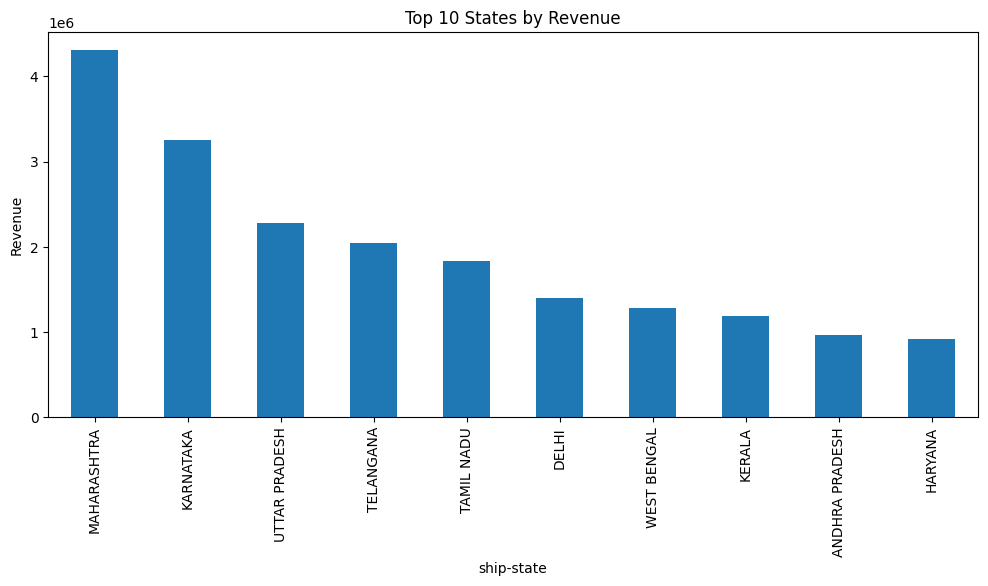

In [45]:
import matplotlib.pyplot as plt

state_revenue.plot(
    kind='bar',
    figsize=(12,5)
)

plt.title("Top 10 States by Revenue")
plt.ylabel("Revenue")
plt.show()

In [46]:
df['Fulfilment'].value_counts()

,count
Fulfilment,
Amazon,28491
Merchant,14327


In [47]:
df.groupby('Fulfilment')['Amount'].sum()

,Amount
Fulfilment,
Amazon,16682618.00
Merchant,8439359.14


In [48]:
fulfillment_cancel_rate = (
    df.assign(Cancelled=df['Status']=='Cancelled')
      .groupby('Fulfilment')['Cancelled']
      .mean()*100
)

fulfillment_cancel_rate

,Cancelled
Fulfilment,
Amazon,12.877751
Merchant,17.651986


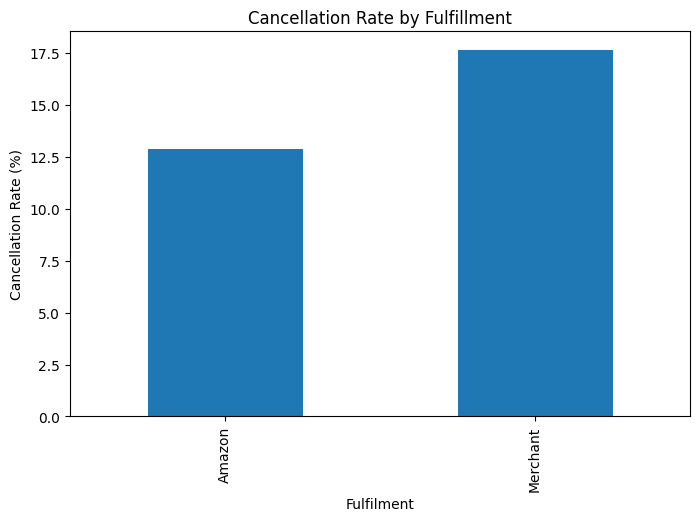

In [49]:
fulfillment_cancel_rate.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Cancellation Rate by Fulfillment")
plt.ylabel("Cancellation Rate (%)")
plt.show()

In [50]:
cancelled_orders = df[df['Status']=='Cancelled']

lost_revenue = cancelled_orders['Amount'].sum()

print(lost_revenue)

2256380.1399999997


In [51]:
cancelled_orders = df[df['Status']=='Cancelled']

lost_revenue = cancelled_orders['Amount'].sum()

print(lost_revenue)

2256380.1399999997


In [52]:
fulfillment_cancel_rate

,Cancelled
Fulfilment,
Amazon,12.877751
Merchant,17.651986


In [53]:
category_summary = pd.DataFrame({
    'Orders': df.groupby('Category').size(),
    'Revenue': df.groupby('Category')['Amount'].sum(),
    'Cancelled_Orders': df[df['Status']=='Cancelled'].groupby('Category').size()
})

category_summary.fillna(0, inplace=True)

category_summary['Cancellation_Rate'] = (
    category_summary['Cancelled_Orders'] /
    category_summary['Orders']
) * 100

category_summary.sort_values(
    'Revenue',
    ascending=False
)

,Orders,Revenue,Cancelled_Orders,Cancellation_Rate
Category,,,,
T-shirt,17461,13432555.78,2559,14.655518
Shirt,17342,7017463.58,2640,15.223158
Blazzer,3762,2616066.78,493,13.104732
Trousers,3329,1550057.69,385,11.565035
Perfume,314,220369.65,45,14.331210
Wallet,373,173992.45,52,13.941019
Socks,169,59960.97,15,8.875740
Shoes,68,51510.24,9,13.235294


In [54]:
df['Amount'].mean()

np.float64(624.645112636133)

In [55]:
df['Category'].value_counts()

,count
Category,
T-shirt,17461
Shirt,17342
Blazzer,3762
Trousers,3329
Wallet,373
Perfume,314
Socks,169
Shoes,68


In [56]:
df['Size'].value_counts()

,count
Size,
L,7422
M,7414
XL,6803
XXL,5808
S,5739
3XL,4925
XS,3830
Free,755
6XL,50


In [57]:
df.groupby('Sales Channel')['Amount'].sum()

,Amount
Sales Channel,
Amazon.in,25121977.14
Non-Amazon,0.00
